# Module 10 - Hierarchical & k-means clustering

*Converted from R Markdown to Python.*

In [28]:
!pip install umap

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import sklearn
import umap
import scipy
import plotnine as p9
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    ggplot,
    geom_hline,
    geom_line,
    geom_path,
    geom_point,
    geom_segment,
    geom_vline,
    guide_legend,
    guides,
    labs,
    scale_color_discrete,
    scale_x_continuous,
    scale_y_continuous,
    theme,
    theme_bw,
)

p9.options.figure_size = (8, 5)


## Data Import

In [30]:
data_url = "https://github.com/gofflab/Quant_mol_neuro_2022/raw/main/modules/module_9/notebooks/GSE63482_Expression_matrix.tsv"
data = pd.read_csv(data_url, sep=" ",index_col=0)
data.head()

,E15_cpn,E15_corticothal,E15_subcereb,E16_cpn,E16_corticothal,E16_subcereb,E18_cpn,E18_corticothal,E18_subcereb,P1_cpn,P1_corticothal,P1_subcereb
gene_id,,,,,,,,,,,,
0610007C21Rik,36.28850,29.69830,33.40490,39.37740,34.43750,30.09790,42.21770,39.85680,32.03480,59.94070,58.40940,54.18620
0610007L01Rik,12.06950,10.96610,10.92010,10.35370,11.00810,12.30130,10.78570,11.41970,11.60680,16.32500,17.05410,14.94610
0610007P08Rik,6.41238,7.04634,7.64108,6.97155,7.23261,6.70851,6.20445,6.60151,4.91168,3.99317,3.80641,3.23802
0610007P14Rik,20.89430,13.67250,14.84450,23.51940,16.24610,28.87290,29.61970,21.17910,36.83880,29.35940,22.10300,32.70000
0610007P22Rik,20.80070,19.68650,21.99760,18.09060,18.25500,19.13760,18.08730,18.06960,17.48320,22.25440,23.98430,24.62150


In [31]:
sample_metadata = data.columns.to_series().str.split("_", n=1, expand=True)
sample_metadata.columns = ["Age", "CellType"]
sample_metadata["SampleID"] = data.columns
sample_metadata = sample_metadata[["SampleID", "Age", "CellType"]]
sample_metadata.head()

,SampleID,Age,CellType
E15_cpn,E15_cpn,E15,cpn
E15_corticothal,E15_corticothal,E15,corticothal
E15_subcereb,E15_subcereb,E15,subcereb
E16_cpn,E16_cpn,E16,cpn
E16_corticothal,E16_corticothal,E16,corticothal


In [32]:
gene_metadata = pd.DataFrame({"geneName": data.index})
gene_metadata.head()

,geneName
0,0610007C21Rik
1,0610007L01Rik
2,0610007P08Rik
3,0610007P14Rik
4,0610007P22Rik


## Clean/process data to cluster

In [33]:
log_fpkm = np.log10(data + 1)
clust_data = log_fpkm[log_fpkm.mean(axis=1) >= 1]
clust_data.shape

(7181, 12)

## Hierarchical clustering

First compute the pairwise distances between samples (columns).

In [34]:
clust_data_t = clust_data.T
euclidean_dist = pdist(clust_data_t, metric="euclidean")
euclidean_dist_matrix = pd.DataFrame(
    squareform(euclidean_dist),
    index=clust_data_t.index,
    columns=clust_data_t.index,
)

def build_dendrogram_frame(linkage_matrix, labels):
    dendro = dendrogram(linkage_matrix, labels=labels, no_plot=True)
    segments = pd.DataFrame(
        {
            "x": [coord for coords in dendro["icoord"] for coord in coords],
            "y": [coord for coords in dendro["dcoord"] for coord in coords],
            "segment": np.repeat(range(len(dendro["icoord"])), 4),
        }
    )
    label_positions = pd.DataFrame(
        {
            "label": dendro["ivl"],
            "x": [5 + 10 * i for i in range(len(dendro["ivl"]))],
        }
    )
    return segments, label_positions

euclidean_dist_matrix.round(2)


,E15_cpn,E15_corticothal,E15_subcereb,E16_cpn,E16_corticothal,E16_subcereb,E18_cpn,E18_corticothal,E18_subcereb,P1_cpn,P1_corticothal,P1_subcereb
E15_cpn,0.00,15.99,12.02,7.74,16.72,14.66,13.10,18.18,18.73,19.16,22.81,24.68
E15_corticothal,15.99,0.00,8.41,15.77,6.47,13.11,16.64,10.92,17.50,20.99,17.89,23.73
E15_subcereb,12.02,8.41,0.00,13.86,10.89,11.72,16.53,14.49,17.57,21.52,20.60,24.06
E16_cpn,7.74,15.77,13.86,0.00,14.66,12.70,7.51,15.49,15.72,15.08,20.39,22.18
E16_corticothal,16.72,6.47,10.89,14.66,0.00,11.14,14.48,6.69,14.90,18.76,15.01,21.51
E16_subcereb,14.66,13.11,11.72,12.70,11.14,0.00,12.46,11.82,8.39,16.37,16.58,16.50
E18_cpn,13.10,16.64,16.53,7.51,14.48,12.46,0.00,13.16,12.47,10.11,17.27,18.57
E18_corticothal,18.18,10.92,14.49,15.49,6.69,11.82,13.16,0.00,12.70,16.00,10.65,18.37
E18_subcereb,18.73,17.50,17.57,15.72,14.90,8.39,12.47,12.70,0.00,13.64,14.59,10.63
P1_cpn,19.16,20.99,21.52,15.08,18.76,16.37,10.11,16.00,13.64,0.00,13.95,13.75


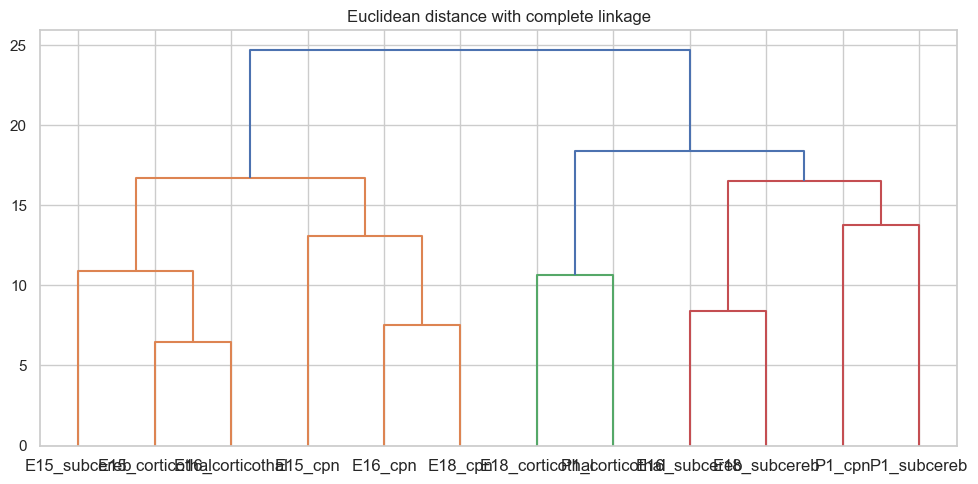

In [35]:
euclidean_linkage = linkage(euclidean_dist, method="complete")
euclidean_segments, euclidean_labels = build_dendrogram_frame(
    euclidean_linkage, clust_data_t.index.tolist()
)

(
    ggplot(euclidean_segments, aes("x", "y", group="segment"))
    + geom_path()
    + scale_x_continuous(
        breaks=euclidean_labels["x"],
        labels=euclidean_labels["label"],
    )
    + labs(
        x="Sample",
        y="Distance",
        title="Euclidean distance with complete linkage",
    )
    + theme_bw()
    + theme(axis_text_x=element_text(angle=45, ha="right"), figure_size=(10, 5))
)


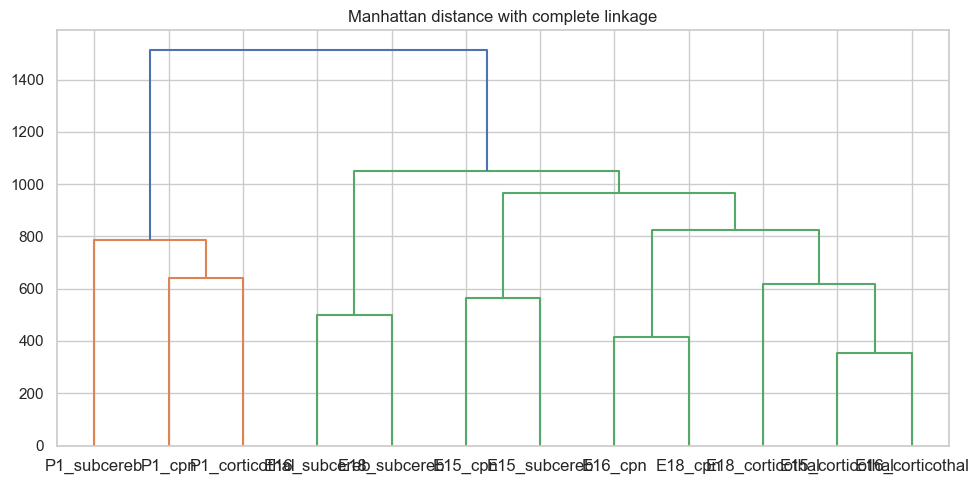

In [36]:
manhattan_dist = pdist(clust_data_t, metric="cityblock")
manhattan_linkage = linkage(manhattan_dist, method="complete")
manhattan_segments, manhattan_labels = build_dendrogram_frame(
    manhattan_linkage, clust_data_t.index.tolist()
)

(
    ggplot(manhattan_segments, aes("x", "y", group="segment"))
    + geom_path()
    + scale_x_continuous(
        breaks=manhattan_labels["x"],
        labels=manhattan_labels["label"],
    )
    + labs(
        x="Sample",
        y="Distance",
        title="Manhattan distance with complete linkage",
    )
    + theme_bw()
    + theme(axis_text_x=element_text(angle=45, ha="right"), figure_size=(10, 5))
)


### Partition by choosing k

In [37]:
k = 3
clusters_k = fcluster(euclidean_linkage, t=k, criterion="maxclust")
pd.Series(clusters_k, index=clust_data_t.index, name="cluster_k3")

E15_cpn            1
E15_corticothal    1
E15_subcereb       1
E16_cpn            1
E16_corticothal    1
E16_subcereb       3
E18_cpn            1
E18_corticothal    2
E18_subcereb       3
P1_cpn             3
P1_corticothal     2
P1_subcereb        3
Name: cluster_k3, dtype: int32

### Partition by fixing height

In [38]:
height = 1000
clusters_height = fcluster(euclidean_linkage, t=height, criterion="distance")
pd.Series(clusters_height, index=clust_data_t.index, name="cluster_height_1000")

E15_cpn            1
E15_corticothal    1
E15_subcereb       1
E16_cpn            1
E16_corticothal    1
E16_subcereb       1
E18_cpn            1
E18_corticothal    1
E18_subcereb       1
P1_cpn             1
P1_corticothal     1
P1_subcereb        1
Name: cluster_height_1000, dtype: int32

## K-means

Scale each gene (row) before clustering so that we focus on expression patterns.

In [39]:
row_means = clust_data.mean(axis=1)
row_stds = clust_data.std(axis=1, ddof=0).replace(0, np.nan)
clust_data_scaled = clust_data.sub(row_means, axis=0).div(row_stds, axis=0).fillna(0)
clust_data_scaled.head()

,E15_cpn,E15_corticothal,E15_subcereb,E16_cpn,E16_corticothal,E16_subcereb,E18_cpn,E18_corticothal,E18_subcereb,P1_cpn,P1_corticothal,P1_subcereb
gene_id,,,,,,,,,,,,
0610007C21Rik,-0.371185,-1.204911,-0.716228,-0.030002,-0.589455,-1.149467,0.261428,0.020597,-0.890441,1.734662,1.625563,1.309441
0610007L01Rik,-0.123527,-0.703743,-0.729080,-1.049319,-0.680695,-0.007880,-0.803670,-0.458995,-0.360636,1.730649,2.001815,1.185082
0610007P14Rik,-0.333328,-1.702849,-1.439904,0.054135,-1.149872,0.729867,0.814354,-0.289106,1.538689,0.785142,-0.149461,1.142334
0610007P22Rik,0.309056,-0.171598,0.798753,-0.907184,-0.828621,-0.417992,-0.908767,-0.917268,-1.203431,0.900494,1.557908,1.788650
0610009B22Rik,1.348276,0.523153,1.221751,0.519586,-0.103763,0.375703,0.123833,-0.291229,0.445020,-2.003603,-1.901321,-0.257405


In [40]:
n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, n_init=50, max_iter=300, random_state=0)
kmeans.fit(clust_data_scaled)
gene_clusters = pd.Series(kmeans.labels_ + 1, index=clust_data_scaled.index, name="cluster")
gene_clusters.head()

gene_id
0610007C21Rik     1
0610007L01Rik     4
0610007P14Rik    10
0610007P22Rik     3
0610009B22Rik    12
Name: cluster, dtype: int32

In [41]:
clust_data_plot = (
    clust_data_scaled
    .assign(cluster=gene_clusters)
    .reset_index()
    .rename(columns={"index": "gene"})
    .melt(id_vars=["gene", "cluster"], var_name="SampleID", value_name="value")
    .merge(sample_metadata, on="SampleID")
)
clust_data_plot.head()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['gene']"

### Summarise data across clusters

In [ ]:
kmeans_summary = (
    clust_data_plot
    .groupby(["cluster", "Age", "CellType"], as_index=False)
    .agg(mean=("value", "mean"), sd=("value", "std"))
)
kmeans_summary.head()

In [ ]:
age_order = sample_metadata["Age"].drop_duplicates().tolist()
cluster_profiles = kmeans_summary.assign(
    Age=pd.Categorical(kmeans_summary["Age"], categories=age_order, ordered=True),
    cluster=kmeans_summary["cluster"].astype(str),
)

(
    ggplot(cluster_profiles, aes("Age", "mean", color="CellType", group="CellType"))
    + geom_line()
    + geom_point()
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + facet_wrap("~cluster", ncol=4)
    + labs(
        x="Age",
        y="Scaled expression",
        title="Cluster-average gene expression profiles",
        color="Cell type",
    )
    + theme_bw()
    + theme(axis_text_x=element_text(angle=45, ha="right"), figure_size=(12, 8))
)


## Clustering QC

### Choosing a k

In [ ]:
k_range = range(2, 31)
wss = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, max_iter=100, random_state=0)
    km.fit(clust_data_scaled)
    wss.append(km.inertia_)
wss

In [ ]:
wss_df = pd.DataFrame({"k": list(k_range), "wss": wss})

(
    ggplot(wss_df, aes("k", "wss"))
    + geom_line()
    + geom_point()
    + scale_x_continuous(breaks=list(range(2, 31, 2)))
    + labs(
        x="Number of clusters (k)",
        y="Within-cluster sum of squares (WSS)",
        title="Elbow method for k selection",
    )
    + theme_bw()
)


In [ ]:
overall_mean = clust_data_scaled.values.mean(axis=0)
tss = ((clust_data_scaled.values - overall_mean) ** 2).sum()
bss = tss - kmeans.inertia_
ratio = bss / tss
print(f"Total within-cluster SS: {kmeans.inertia_:,.2f}")
print(f"Between-cluster SS: {bss:,.2f}")
print(f"BSS/TSS ratio: {ratio:.3f}")

### Silhouette method

In [ ]:
silhouette_avg = silhouette_score(clust_data_scaled, gene_clusters)
sample_silhouette_values = silhouette_samples(clust_data_scaled, gene_clusters)
print(f"Average silhouette score for k={n_clusters}: {silhouette_avg:.3f}")

In [ ]:
silhouette_scores = pd.DataFrame({"k": list(k_range), "avg_score": avg_silhouette_scores})

(
    ggplot(silhouette_scores, aes("k", "avg_score"))
    + geom_line()
    + geom_point()
    + scale_x_continuous(breaks=list(range(2, 31, 2)))
    + labs(
        x="Number of clusters (k)",
        y="Average silhouette score",
        title="Silhouette scores across k",
    )
    + theme_bw()
)


In [ ]:
silhouette_rows = []
silhouette_labels = []
y_lower = 10
for cluster_id in sorted(gene_clusters.unique()):
    values = np.sort(sample_silhouette_values[gene_clusters == cluster_id])
    size = len(values)
    y_upper = y_lower + size
    y_values = np.arange(y_lower, y_upper)
    silhouette_rows.append(
        pd.DataFrame(
            {
                "cluster": str(cluster_id),
                "silhouette": values,
                "y": y_values,
            }
        )
    )
    silhouette_labels.append({"cluster": str(cluster_id), "y": y_lower + (size - 1) / 2})
    y_lower = y_upper + 10

silhouette_plot_df = pd.concat(silhouette_rows, ignore_index=True)
silhouette_label_df = pd.DataFrame(silhouette_labels)

(
    ggplot(silhouette_plot_df, aes("silhouette", "y", color="cluster"))
    + geom_segment(aes(x=0, xend="silhouette", y="y", yend="y"), size=1)
    + geom_vline(xintercept=silhouette_avg, linetype="dashed", color="red")
    + scale_y_continuous(
        breaks=silhouette_label_df["y"],
        labels=silhouette_label_df["cluster"],
    )
    + labs(
        x="Silhouette coefficient",
        y="Cluster label",
        title="Silhouette plot for k-means clustering",
        color="Cluster",
    )
    + theme_bw()
    + theme(axis_text_y=element_text(), figure_size=(8, 6))
)


## UMAP on genes to visualize cluster relationships

In [ ]:
reducer = umap.UMAP(random_state=0)
genes_umap = reducer.fit_transform(clust_data_scaled)
genes_umap_df = (
    pd.DataFrame(genes_umap, columns=["UMAP1", "UMAP2"])
    .assign(
        gene=clust_data_scaled.index,
        cluster=gene_clusters.astype(str).values,
    )
)

umap_plot = (
    ggplot(genes_umap_df, aes("UMAP1", "UMAP2"))
    + geom_point(alpha=0.7, size=1.5)
    + labs(title="UMAP of genes", x="UMAP 1", y="UMAP 2")
    + theme_bw()
    + theme(figure_size=(6, 5))
)

umap_cluster_plot = (
    ggplot(genes_umap_df, aes("UMAP1", "UMAP2", color="cluster"))
    + geom_point(alpha=0.7, size=1.5)
    + labs(
        title="UMAP colored by k-means cluster",
        x="UMAP 1",
        y="UMAP 2",
        color="Cluster",
    )
    + theme_bw()
    + guides(color=guide_legend(title="Cluster"))
    + theme(figure_size=(6, 5))
)

umap_plot
umap_cluster_plot


## Session Information

In [ ]:
import sys
import platform
import plotnine

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"plotnine: {plotnine.__version__}")
print(f"umap: {umap.__version__}")
